# Oppgåver til Demo sklearn

Me skal ta for oss eit enkelt datasett med lønsdata, som eg har henta frå
[Kaggle](https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression?resource=download).

+ **Datafil** [Salary_dataset.csv](Salary_dataset.csv)

Ifylgje dokumentasjonen på Kaggle, er der to søyler forutan indeks:
løn og erfaring i år.
Me kan altso freista å predikera lønen som ein funksjon av erfaringa i år.

## Datasettet i pandas

In [7]:
import pandas as pd
df = pd.read_csv( "Salary_dataset.csv" )
display( df )

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


<Axes: xlabel='YearsExperience', ylabel='Salary'>

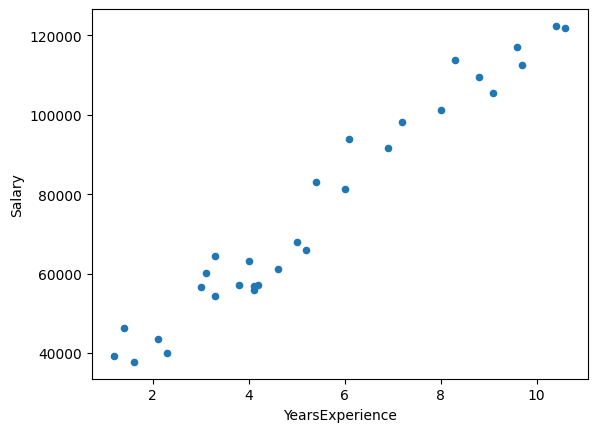

In [8]:
df.plot.scatter( "YearsExperience", "Salary" )

## Datasettet i sklearn

In [108]:
import sklearn as sk

In [118]:
X = df[ [ "YearsExperience" ] ]
display( X )

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3
5,3.0
6,3.1
7,3.3
8,3.3
9,3.8


In [120]:
Y = df[ "Salary" ]
display( Y )

0      39344.0
1      46206.0
2      37732.0
3      43526.0
4      39892.0
5      56643.0
6      60151.0
7      54446.0
8      64446.0
9      57190.0
10     63219.0
11     55795.0
12     56958.0
13     57082.0
14     61112.0
15     67939.0
16     66030.0
17     83089.0
18     81364.0
19     93941.0
20     91739.0
21     98274.0
22    101303.0
23    113813.0
24    109432.0
25    105583.0
26    116970.0
27    112636.0
28    122392.0
29    121873.0
Name: Salary, dtype: float64

In [121]:
trainX, testX, trainY, testY = sk.model_selection.train_test_split( X, Y )

## Trening av modellen

In [122]:
model = sk.linear_model.LinearRegression()

In [125]:
print( model )

LinearRegression()


In [126]:
model.fit( trainX, trainY )

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Prediksjon

In [127]:
predY = model.predict( testX )

In [128]:
predY

array([103097.21499886,  38453.70505762,  72180.75372262,  53443.50446429,
        62812.12909345,  60938.40416762,  64685.85401928,  63748.99155637])

In [129]:
predY - testY

23   -10715.785001
1     -7752.294942
15     4241.753723
5     -3199.495536
10     -406.870907
9      3748.404168
13     7603.854019
11     7953.991556
Name: Salary, dtype: float64

In [131]:
errors = predY - testY
print( errors )

23   -10715.785001
1     -7752.294942
15     4241.753723
5     -3199.495536
10     -406.870907
9      3748.404168
13     7603.854019
11     7953.991556
Name: Salary, dtype: float64


In [133]:
errors = errors.abs()
print( errors )

23    10715.785001
1      7752.294942
15     4241.753723
5      3199.495536
10      406.870907
9      3748.404168
13     7603.854019
11     7953.991556
Name: Salary, dtype: float64


In [134]:
errors.describe()

count        8.000000
mean      5702.806231
std       3344.078678
min        406.870907
25%       3611.177010
50%       5922.803871
75%       7802.719096
max      10715.785001
Name: Salary, dtype: float64

In [135]:
relerrors = errors / testY
print( relerrors )

23    0.094153
1     0.167777
15    0.062435
5     0.056485
10    0.006436
9     0.065543
13    0.133209
11    0.142557
Name: Salary, dtype: float64


In [136]:
relerrors.describe()

count    8.000000
mean     0.091074
std      0.053653
min      0.006436
25%      0.060947
50%      0.079848
75%      0.135546
max      0.167777
Name: Salary, dtype: float64

## Visualisering av feilanalysen

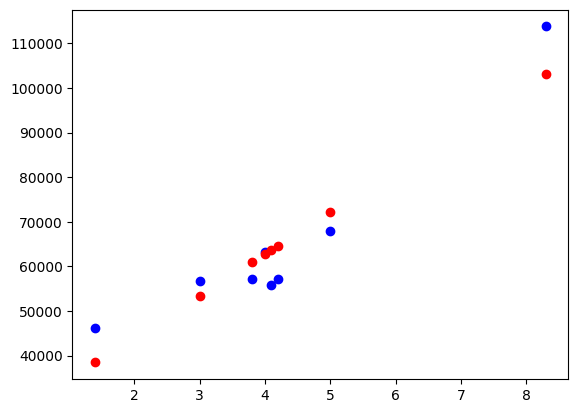

In [139]:
import matplotlib.pyplot as plt
plt.scatter( testX, testY, color="b" )
plt.scatter( testX, predY, color="r" )